In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.metrics import MetricFrame, selection_rate
import warnings
warnings.filterwarnings("ignore")





In [11]:
# Simulate biased dataset
np.random.seed(42)
n = 1000
data = pd.DataFrame({
    'experience': np.random.normal(5, 2, n).clip(0, 10),
    'education': np.random.randint(1, 6, n),
    'gender': np.random.choice([0, 1], n, p=[0.4, 0.6]),  # More males
    'shortlisted': np.random.choice([0, 1], n, p=[0.7, 0.3])  # Base rate
})
# Introduce bias: Males are more likely to be shortlisted
data['shortlisted'] = np.where(
    (data['gender'] == 1) & (data['experience'] > 4), 
    np.random.choice([0, 1], len(data), p=[0.3, 0.7]), 
    data['shortlisted']
)

print(data.head())

   experience  education  gender  shortlisted
0    5.993428          4       0            0
1    4.723471          1       1            1
2    6.295377          3       0            0
3    8.046060          5       0            1
4    4.531693          3       0            0


In [12]:
# Features and target
X = data[['experience', 'education']]  # Start without gender
y = data['shortlisted']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



# Predict


# Basic evaluation


In [13]:
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [14]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.60


In [15]:
# Include gender in features
X_full = data[['experience', 'education', 'gender']]
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y, test_size=0.3, random_state=42)

model_full = LogisticRegression()
model_full.fit(X_train_full, y_train_full)
y_pred_full = model_full.predict(X_test_full)

# Fairness analysis
sensitive_feature = X_test_full['gender']  # Gender as sensitive attribute

# MetricFrame for fairness by group
metrics = MetricFrame(
    metrics={'accuracy': accuracy_score, 'selection_rate': selection_rate},
    y_true=y_test_full,
    y_pred=y_pred_full,
    sensitive_features=sensitive_feature
)

print("Fairness Metrics by Gender:")
print(metrics.by_group)

# Disparate impact: Ratio of selection rates (should be ~1 for fairness)
di = metrics.by_group['selection_rate'][1] / metrics.by_group['selection_rate'][0]
print(f"Disparate Impact (Male/Female): {di:.2f}")
# Ethical note: <1.0 indicates bias against females; aim for 0.8-1.25 range.

Fairness Metrics by Gender:
        accuracy  selection_rate
gender                          
0       0.628319        0.000000
1       0.631016        0.914439
Disparate Impact (Male/Female): inf


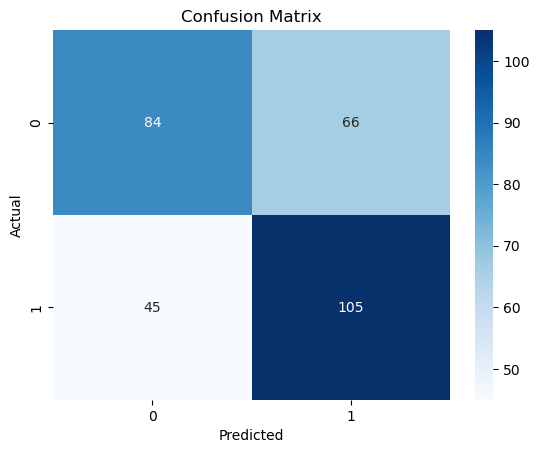

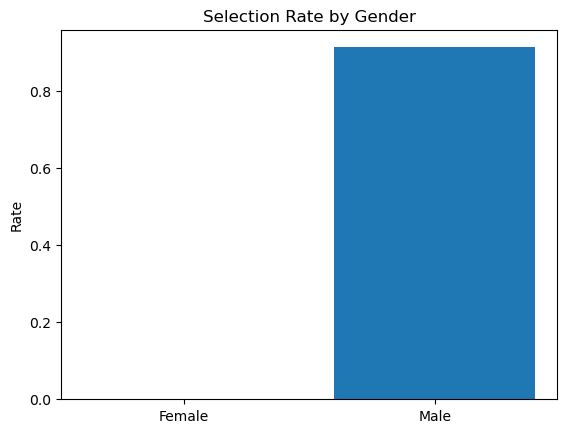

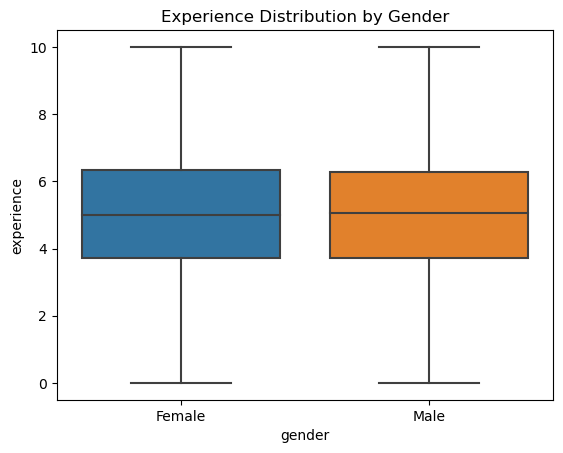

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test_full, y_pred_full)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Selection rate by gender
plt.bar(['Female', 'Male'], metrics.by_group['selection_rate'])
plt.title('Selection Rate by Gender')
plt.ylabel('Rate')
plt.show()

# Distribution of experience by gender
sns.boxplot(x='gender', y='experience', data=data)
plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Experience Distribution by Gender')
plt.show()